**H011: Pricing of exotic options**

Author: Mario Martínez Escrivá

In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from my_option_pricing import (
    price_european_option_MC,
    price_geometric_mean_call_option,
    sensitivities_european_call_option,
    price_exotic_option_MC,
    pricing_control_variate_MC,
)

from scipy.stats import norm, lognorm
from numpy.random import default_rng

from tools_qfb import compare_histogram_pdf

from stochastic_processes import simulate_geometric_brownian_motion


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Simulation of arithmetic Brownian motion.

Let us simulate (arithmetic) Brownian motion trajectories in the interval $\left[t_0, t_0+T \right]$.

To this end, we define a set of monitoring points (also known as the integration grid):
$$
\left\{t_n \right\}_{n=0}^N = \left(t_0, t_1, \ldots, t_N\right), 
$$
with $t_N = t_0 + T$.

The corresponding measurements (monitored values) of the process are:
$$
\left\{B_n = B(t_n)  \right\}_{n=0}^N = \left(B(t_0), B(t_1),  \ldots, B(t_N)\right).
$$

In this model, the simulation of $M$ trajectories in $N$ steps is defined iteratively as:
\begin{align*}
B_0^{(m)} &= B_0 \\
B_{n+1}^{(m)} &= B_{n}^{(m)} + \left(\mu \Delta t_n + \sigma \sqrt{\Delta t_n} X_n^{(m)} \right) \\ 
X_n^{(m)} &\sim \mathcal{N}(0, 1), \quad n = 0, \ldots, N-1 \\
m &= 1, \ldots, M
\end{align*}

with the time increments defined as:
$$
\Delta t_n = t_{n+1} - t_{n}, \quad n = 0, \ldots, N-1.
$$

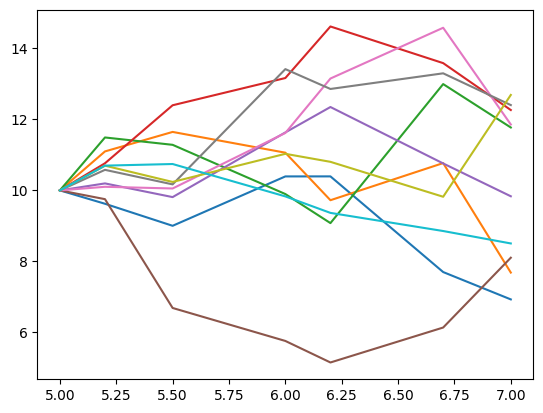

In [10]:
B_0 = 10.0
t_0 = 5.0
t = t_0 + np.array([0.0, 0.2, 0.5, 1.0, 1.2, 1.7, 2.0])

mu, sigma = 0.5, 2.0

delta_T = np.diff(t)
n_steps = len(delta_T) 
n_trajectories = 10
d = (
    mu *delta_T 
    + sigma * np.sqrt(delta_T) 
      * np.random.standard_normal((n_trajectories, n_steps))
) 

B = np.empty((n_trajectories, n_steps + 1))

"""
# Sin vectorizar
for m in range(n_trajectories):
    B[m, 0] = B_0
    for n in range(n_steps):
        B[m, n + 1] = B[m, n] + d[m, n]
"""
"""
# Vectorización sobre trayectorias
B[:, 0] = B_0
for n in range(n_steps):
    B[:, n + 1] = B[:, n] + d[:, n]
"""
# Vectorización sobre trayectorias y tiempos

B[:, 0] = B_0
print('')
B[:, 1:] = d
B = np.cumsum(B, axis=1)

fig, ax = plt.subplots()
_ = ax.plot(t, B.T)

# Black-Scholes model: Simulation

Let us simulate the evolution of the price of an asset in the interval $\left[t_0, t_0+T \right]$.

To this end, we define a set of monitoring points (also known as the integration grid):
$$
\left\{t_n \right\}_{n=0}^N = \left(t_0, t_1, \ldots, t_N\right), 
$$
with $t_N = t_0 + T$.

The corresponding measurements (monitored values) of the process are:
$$
\left\{S_n = S(t_n)  \right\}_{n=0}^N = \left(S(t_0), S(t_1),  \ldots, S(t_N)\right).
$$

In the Black-Scholes model, the simulation of the process for $M$ trajectories and $N$ timesteps is defined iteratively as:
\begin{align*}
S_0^{(m)} &= S_0 \\
S_{n+1}^{(m)} &= S_{n}^{(m)} \exp \left\{ \left(\mu-\frac{1}{2}\sigma^2 \right) \Delta t_n + \sigma \sqrt{\Delta t_n} X_n^{(m)} \right\} \\ 
X_n^{(m)} &\sim \mathcal{N}(0, 1), \quad n = 0, \ldots, N-1 \\
m &= 1, \ldots, M
\end{align*}

with the time increments defined as:
$$
\Delta t_n = t_{n+1} - t_{n}, \quad n = 0, \ldots, N-1.
$$


# Risk-neutral simulation of the evolution of the underlying in the Black-Scholes Model.

In [11]:
from numpy.random import default_rng

# Characteristics of the underlying.
S_0, mu, sigma = 100.0, 0.15, 0.30

# Initial time and length of the simulation.
t_0, T = 5.0, 3.0

# Risk-free interest rate.
r = 0.05

# Payoff function
K = 80  # Strike
payoff_call = lambda S: np.maximum(S - K, 0.0)  


# Number of simulated trajectories.
n_trajectories = 10000  

# Setup integration grid
times = np.linspace(t_0, t_0 + T, num=1000)
n_times = len(times)
delta_T = np.diff(times)

# The simulation is stored in an array. 
# Each row of this array corresponds to a trajectory in the simulation.
S = np.empty((n_trajectories, n_times))

# Gausssian White noise
seed=0
rng = default_rng(seed=seed)
X = rng.standard_normal((n_trajectories, n_times-1))  

# Black-scholes model (risk neutral)
S[:, 0] = S_0
S[:, 1:] = np.exp(
    (r - 0.5*sigma**2) * delta_T 
    + sigma * np.sqrt(delta_T) * X
)
S = np.cumprod(S, axis=1)

# IMP: Check https://numpy.org/doc/stable/user/basics.broadcasting.html

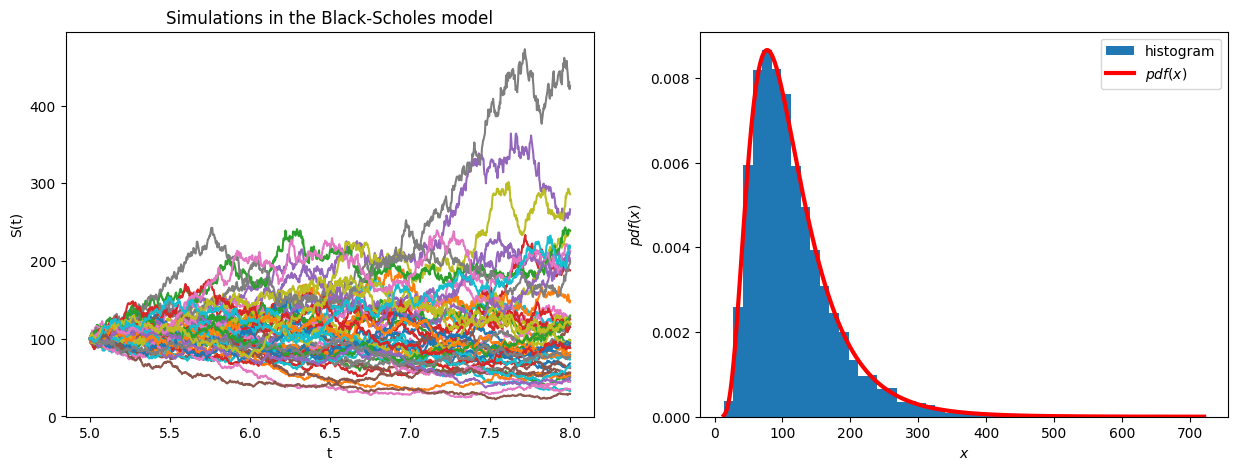

In [12]:
# Plot the trajectories simulated

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(times, S[:50, :].T)
axs[0].set_xlabel('t')
axs[0].set_ylabel('S(t)')
_ = axs[0].set_title('Simulations in the Black-Scholes model')

# In the Black-Scholes model, prices are distributed as a Lognormal. 

S_T = S[:,-1]

_ = compare_histogram_pdf(
    S_T, 
    lambda x: lognorm.pdf(x, 
                          s=sigma * np.sqrt(T), 
                          scale=S_0*np.exp((r - 0.5*sigma**2) * T)),
    n_bins=50,
    ax=axs[1],
)

# Pricing a European call option

Price (MC estimate): 36.2813
Stdev (MC estimate): 0.4978
3.0


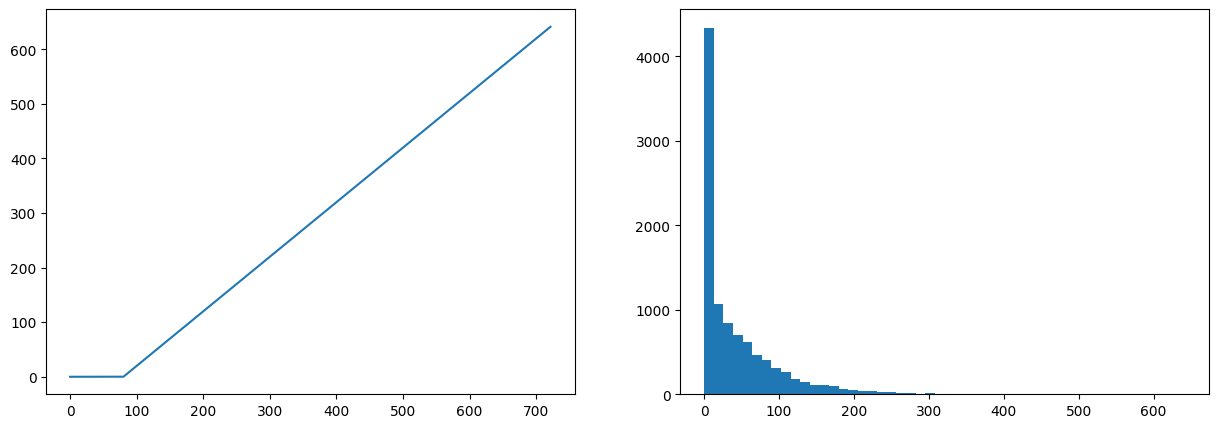

In [13]:
# EU Call option

# Plot payoff function

S_plot = np.linspace(0, np.max(S_T), num=1000)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
_ = axs[0].plot(S_plot, payoff_call(S_plot))


# Simulated Payoffs
payoff_T = payoff_call(S_T)
_ = axs[1].hist(payoff_T, bins=50)

discount_factor = np.exp(-r * T)
price_MC = discount_factor * np.mean(payoff_T)
stdev_MC = discount_factor * np.std(payoff_T) / np.sqrt(n_trajectories)

# Monte Carlo pricing

print('Price (MC estimate):', np.round(price_MC, 4))
print('Stdev (MC estimate):', np.round(stdev_MC, 4))
print(T)

To validate our risk-neutral simulation, we can compare the Monte Carlo estimate against the exact theoretical price given by the Black-Scholes formula. 

For the chosen parameters ($S_0=100, K=80, r=0.05, \sigma=0.30, T=3$), the exact Black-Scholes price for a European Call is $37.01$.

Our Monte Carlo simulation ($M=10000$ trajectories) yielded:
* Estimated price: $36.28$
* Standard error (SE): $0.50$

Calculating the 95% confidence interval ($\hat{C}_0 \pm 1.96 \times SE$):
$$CI_{95\%} = [35.30, \ 37.26]$$

Because the theoretical exact price ($37.01$) falls comfortably within our 95% confidence interval, we can conclude that the lognormal asset simulation and the pricing algorithm are functioning perfectly.

# Pricing Asian options

In [24]:
# Call on the geometric mean (Asian)

price_geometric_mean_exact = price_geometric_mean_call_option(
    S_0, K, r, T, sigma, n_times - 1
)

# Monte Carlo simulation of the call on the geometric mean

# Geometric mean per trajectory
S_geometric_mean = np.exp(np.mean(np.log(S[:, 1:]), axis=1))  


payoff_geometric_mean_MC = payoff_call(S_geometric_mean)
discount_factor = np.exp(- r * T)
price_geometric_mean_MC = (
    discount_factor * np.mean(payoff_geometric_mean_MC))
stdev_geometric_mean_MC = (
    discount_factor * np.std(payoff_geometric_mean_MC) 
    / np.sqrt(n_trajectories))

print('Call on the geometric mean')

print('price (exact) = {:.2f}'.format(
    price_geometric_mean_exact))
print('price (MC) = {:.2f} ({:.2f})'.format(
    price_geometric_mean_MC, stdev_geometric_mean_MC))

Call on the geometric mean
price (exact) = 24.15
price (MC) = 23.77 (0.25)


In [25]:
# Call on the arithmetic mean (Asian)

# Arithmetic mean per trajectory
S_arithmetic_mean = np.mean(S[:, 1:], axis=1)  

payoff_arithmetic_mean_MC = payoff_call(S_arithmetic_mean)
discount_factor = np.exp(- r * T)
price_arithmetic_mean_MC = (
    discount_factor 
    * np.mean(payoff_arithmetic_mean_MC)
)
stdev_arithmetic_mean_MC = (
    discount_factor 
    * np.std(payoff_arithmetic_mean_MC) 
    / np.sqrt(n_trajectories)
)
print('price (MC) = {:.2f} ({:.2f})'.format(
    price_arithmetic_mean_MC, stdev_arithmetic_mean_MC)
) 

price (MC) = 25.53 (0.27)


In [26]:
# Variance reduction for call option on the arithmetic mean
# using the call option on the geometric mean as control variate.
# IMPORTANT: Use common random numbers for both types of option.

covariance_matrix_aritmetic_geometric = np.cov(
    payoff_arithmetic_mean_MC, 
    payoff_geometric_mean_MC
)
price_arithmetic_mean_MC_CV = (
    price_arithmetic_mean_MC 
    - covariance_matrix_aritmetic_geometric[0, 1] 
    / covariance_matrix_aritmetic_geometric[1, 1]
    * (price_geometric_mean_MC - price_geometric_mean_exact)
)
rho_square = (
    covariance_matrix_aritmetic_geometric[0, 1]**2 
    / (covariance_matrix_aritmetic_geometric[0, 0]
       * covariance_matrix_aritmetic_geometric[1, 1])
)
stdev_arithmetic_mean_MC_CV = (
    np.sqrt(1.0 - rho_square) 
    * stdev_arithmetic_mean_MC
)

print('Call on the arithmetic mean')

print('price (MC) = {:.3f} ({:.3f})'.format(
    price_arithmetic_mean_MC, stdev_arithmetic_mean_MC))
print('price (MC + CV) = {:.3f} ({:.3f})'.format(
    price_arithmetic_mean_MC_CV, stdev_arithmetic_mean_MC_CV)) 

Call on the arithmetic mean
price (MC) = 25.528 (0.267)
price (MC + CV) = 25.931 (0.018)


In [27]:
from scipy.stats import gmean

# Target Option: Call on the Arithmetic Mean
def payoff(S_T):
    return np.maximum(np.mean(S_T[:, 1:], axis=1) - K, 0.0)

# Control Option: Call on the Geometric Mean
def payoff_control(S_T):
    return np.maximum(gmean(S_T[:, 1:], axis=1) - K, 0.0)

# Analytical Exact Price of the Control Option
def price_control(S_0_val, r_val, T_val, sigma_val): 
    # Notice we use the global K and n_times here
    return price_geometric_mean_call_option(
        S_0_val, K, r_val, T_val, sigma_val, n_times - 1
    )


# Pricing Execution using my_option_pricing.py

# Standard Monte Carlo Pricing (Arithmetic Mean)
price_arithmetic_MC, stdev_arithmetic_MC = price_exotic_option_MC(
    S_0, r, times, sigma, payoff, n_trajectories, seed=42
)

# Monte Carlo with Control Variate (Arithmetic Mean)
price_MC_CV, stdev_MC_CV = pricing_control_variate_MC(
    S_0, r, times, sigma, 
    payoff, payoff_control, price_control, 
    n_trajectories, seed=42
)

# Display Results
print('--- Asian Call on the Arithmetic Mean ---')
print('Price (MC)      = {:.3f} (SE: {:.3f})'.format(price_arithmetic_MC, stdev_arithmetic_MC))
print('Price (MC + CV) = {:.3f} (SE: {:.3f})'.format(price_MC_CV, stdev_MC_CV))

# Calculate Variance Reduction Factor
reduction_factor = stdev_arithmetic_MC / stdev_MC_CV
print('\nVariance Reduction Factor = {:.1f}x'.format(reduction_factor))

--- Asian Call on the Arithmetic Mean ---
Price (MC)      = 26.003 (SE: 0.274)
Price (MC + CV) = 25.927 (SE: 0.019)

Variance Reduction Factor = 14.7x


The outputs from both the manual step-by-step calculations and our modular functions confirm the tremendous power of the Control Variate technique for pricing exotic derivatives.

**Arithmetic vs. Geometric Asian options:**

As expected by Jensen's inequality, the arithmetic mean of a set of positive numbers is always strictly greater than or equal to their geometric mean. Consequently, the payoff—and thus the price—of the arithmetic Asian call (`~25.93`) is inherently higher than that of the geometric Asian call (`~24.15`). 

**The geometric option as a control variate:**

Because there is no closed-form analytical solution for an arithmetic Asian option, we rely on Monte Carlo simulation. However, standard MC yields a relatively high standard error (`~0.274`). 
Since the arithmetic and geometric averages are evaluated over the exact same simulated underlying paths (using common random numbers), their payoffs are highly correlated. This makes the geometric Asian option (which *does* have an exact analytical Black-Scholes-style solution) an ideal control variate.

**Computational efficiency (variance reduction factor):**

By applying the control variate, the standard error plummeted from `0.274` to `0.019`, achieving a variance reduction Factor of 14.7x.
* In standard Monte Carlo, the standard error shrinks at a rate of $1/\sqrt{N}$. 
* To achieve this exact same error reduction using standard Monte Carlo, we would have needed to increase the number of simulated trajectories by a factor of $14.7^2 \approx 216$. 

**Conclusion:**
Using the control variate method, we obtained a highly precise, statistically stable price estimate for the arithmetic Asian option (`25.927`) at a fraction of the computational cost required by a brute-force simulation.